テーマ：犬と猫の画像分類AI


解決したい課題: 与えられた画像が犬か猫かを自動的に識別する。

目標: 高い精度で犬と猫を分類できるAIモデルを構築する。

データの準備：データセットのダウンロードと解凍

In [28]:
# --- 標準ライブラリ ---
import os
import zipfile
import shutil
import random

# --- 数値計算・データ操作 ---
import numpy as np
import pandas as pd

# --- グラフ描画 ---
import matplotlib.pyplot as plt

# --- ディープラーニング (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 # またはVGG19など、使用する事前学習モデル

# --- モデル評価 (scikit-learn) ---
from sklearn.model_selection import train_test_split # 今回は手動分割だが汎用的に含めておく
from sklearn.metrics import classification_report, confusion_matrix # 評価レポートと混同行列用

# --- pandasの表示設定 (必要に応じて) ---
pd.options.display.max_columns = None

In [29]:
# Kaggle APIライブラリのインストール
!pip install kaggle

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# ダウンロード先ディレクトリ
dataset_dir = 'dogs_vs_cats_dataset'

# dataset_dir内にdogs-cats-images.zipがあることを確認
zip_path = os.path.join(dataset_dir, 'dogs-cats-images.zip')

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

original_train_dir = os.path.join(dataset_dir, 'dataset', 'training_set')
original_test_dir = os.path.join(dataset_dir, 'dataset', 'test_set')

print(f"オリジナル訓練データ: {len(os.listdir(os.path.join(original_train_dir, 'dogs')))} dogs, {len(os.listdir(os.path.join(original_train_dir, 'cats')))} cats")
print(f"オリジナルテストデータ: {len(os.listdir(os.path.join(original_test_dir, 'dogs')))} dogs, {len(os.listdir(os.path.join(original_test_dir, 'cats')))} cats")

オリジナル訓練データ: 4000 dogs, 4000 cats
オリジナルテストデータ: 1000 dogs, 1000 cats


データの準備２：訓練、検証、テスト用ディレクトリ構造の作成とデータの分割

In [31]:
# 新しいベースディレクトリ
base_dir = 'cats_and_dogs_small'
os.makedirs(base_dir, exist_ok=True)

# 訓練、検証、テスト用のディレクトリを作成
train_dir = os.path.join(base_dir, 'train')
os.makedirs(train_dir, exist_ok=True)
validation_dir = os.path.join(base_dir, 'validation')
os.makedirs(validation_dir, exist_ok=True)
test_dir = os.path.join(base_dir, 'test')
os.makedirs(test_dir, exist_ok=True)

In [32]:
# クラスごとのディレクトリを作成
train_cats_dir = os.path.join(train_dir, 'cats')
os.makedirs(train_cats_dir, exist_ok=True)
train_dogs_dir = os.path.join(train_dir, 'dogs')
os.makedirs(train_dogs_dir, exist_ok=True)

validation_cats_dir = os.path.join(validation_dir, 'cats')
os.makedirs(validation_cats_dir, exist_ok=True)
validation_dogs_dir = os.path.join(validation_dir, 'dogs')
os.makedirs(validation_dogs_dir, exist_ok=True)

test_cats_dir = os.path.join(test_dir, 'cats')
os.makedirs(test_cats_dir, exist_ok=True)
test_dogs_dir = os.path.join(test_dir, 'dogs')
os.makedirs(test_dogs_dir, exist_ok=True)

In [33]:
# オリジナルデータセットのパス 
original_train_cats_dir = os.path.join(dataset_dir, 'dataset', 'training_set', 'cats')
original_train_dogs_dir = os.path.join(dataset_dir, 'dataset', 'training_set', 'dogs')
original_test_cats_dir = os.path.join(dataset_dir, 'dataset', 'test_set', 'cats')
original_test_dogs_dir = os.path.join(dataset_dir, 'dataset', 'test_set', 'dogs')

In [34]:
# データの分割とコピー関数
def split_data(source_dir, train_dest_dir, validation_dest_dir, test_dest_dir, split_ratio_val=0.2, split_ratio_test=0.5):
    all_files = [os.path.join(source_dir, fname) for fname in os.listdir(source_dir) if fname.endswith('.jpg')]
    
    # 訓練用データから検証用データを分割
    num_val_samples = int(len(all_files) * split_ratio_val)
    
    # テスト用データは別途用意されているので、ここでは訓練データから検証データを分割するのみ
    # Kaggleのデータセットは既にtraining_setとtest_setに分かれているので、
    # training_setをtrainとvalidationに分割し、test_setはそのままtestとして使う
    
    # Kaggleのtraining_setを train_new と validation に分割
    # Kaggleのtest_setを test_new として使う
    
    # training_setのファイルをリストアップ
    train_cat_fnames = [os.path.join(original_train_cats_dir, fname) for fname in os.listdir(original_train_cats_dir) if fname.endswith('.jpg')]
    train_dog_fnames = [os.path.join(original_train_dogs_dir, fname) for fname in os.listdir(original_train_dogs_dir) if fname.endswith('.jpg')]

    # シャッフル
    import random
    random.shuffle(train_cat_fnames)
    random.shuffle(train_dog_fnames)

    # 訓練データと検証データに分割
    num_val_cats = int(len(train_cat_fnames) * split_ratio_val)
    num_val_dogs = int(len(train_dog_fnames) * split_ratio_val)

    val_cat_fnames = train_cat_fnames[:num_val_cats]
    train_cat_fnames_new = train_cat_fnames[num_val_cats:]

    val_dog_fnames = train_dog_fnames[:num_val_dogs]
    train_dog_fnames_new = train_dog_fnames[num_val_dogs:]

    print(f"猫の訓練データ: {len(train_cat_fnames_new)}枚, 検証データ: {len(val_cat_fnames)}枚")
    print(f"犬の訓練データ: {len(train_dog_fnames_new)}枚, 検証データ: {len(val_dog_fnames)}枚")

    # ファイルをコピー
    for fname in train_cat_fnames_new:
        shutil.copyfile(fname, os.path.join(train_cats_dir, os.path.basename(fname)))
    for fname in val_cat_fnames:
        shutil.copyfile(fname, os.path.join(validation_cats_dir, os.path.basename(fname)))

    for fname in train_dog_fnames_new:
        shutil.copyfile(fname, os.path.join(train_dogs_dir, os.path.basename(fname)))
    for fname in val_dog_fnames:
        shutil.copyfile(fname, os.path.join(validation_dogs_dir, os.path.basename(fname)))

    # オリジナルのtest_setをそのまま新しいtest_dirにコピー
    for fname in os.listdir(original_test_cats_dir):
        if fname.endswith('.jpg'):
            shutil.copyfile(os.path.join(original_test_cats_dir, fname), os.path.join(test_cats_dir, fname))
    for fname in os.listdir(original_test_dogs_dir):
        if fname.endswith('.jpg'):
            shutil.copyfile(os.path.join(original_test_dogs_dir, fname), os.path.join(test_dogs_dir, fname))


In [35]:
# データの分割とコピーを実行
# training_setから訓練と検証に分割し、test_setはそのままテストとして使用
# 検証データの割合を20%とする
split_data(original_train_cats_dir, train_cats_dir, validation_cats_dir, test_cats_dir, split_ratio_val=0.2)
split_data(original_train_dogs_dir, train_dogs_dir, validation_dogs_dir, test_dogs_dir, split_ratio_val=0.2)

print("\nデータ分割とコピーが完了")
print(f"訓練用猫画像: {len(os.listdir(train_cats_dir))}枚")
print(f"訓練用犬画像: {len(os.listdir(train_dogs_dir))}枚")
print(f"検証用猫画像: {len(os.listdir(validation_cats_dir))}枚")
print(f"検証用犬画像: {len(os.listdir(validation_dogs_dir))}枚")
print(f"テスト用猫画像: {len(os.listdir(test_cats_dir))}枚")
print(f"テスト用犬画像: {len(os.listdir(test_dogs_dir))}枚")

猫の訓練データ: 3200枚, 検証データ: 800枚
犬の訓練データ: 3200枚, 検証データ: 800枚
猫の訓練データ: 3200枚, 検証データ: 800枚
犬の訓練データ: 3200枚, 検証データ: 800枚

データ分割とコピーが完了
訓練用猫画像: 3996枚
訓練用犬画像: 3990枚
検証用猫画像: 2408枚
検証用犬画像: 2355枚
テスト用猫画像: 1000枚
テスト用犬画像: 1000枚


データの準備３：ImageDataGeneratorを使ったデータ拡張と前処理

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

# 画像のサイズ
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32 # バッチサイズ

# --- 訓練用データジェネレーター ---
# データ拡張と正規化 (0-1の範囲にスケーリング)
train_datagen = ImageDataGenerator(
    rescale=1./255,             # ピクセル値を0-1に正規化
    rotation_range=40,          # ランダムに画像を40度まで回転
    width_shift_range=0.2,      # ランダムに水平方向に20%までシフト
    height_shift_range=0.2,     # ランダムに垂直方向に20%までシフト
    shear_range=0.2,            # シアー変換をランダムに適用
    zoom_range=0.2,             # ランダムにズーム
    horizontal_flip=True,       # ランダムに水平方向に反転
    fill_mode='nearest'         # 新しく生成されたピクセルを近くのピクセルで埋める
)

# --- 検証用データジェネレーター ---
# 検証データにはデータ拡張は適用せず、正規化のみ
validation_datagen = ImageDataGenerator(rescale=1./255)

# --- テスト用データジェネレーター ---
# テストデータにもデータ拡張は適用せず、正規化のみ
test_datagen = ImageDataGenerator(rescale=1./255)



In [37]:
# --- ディレクトリから画像をロードするジェネレーターを作成 ---
# 訓練データ
train_generator = train_datagen.flow_from_directory(
    train_dir,                  # 訓練データのディレクトリ
    target_size=(IMG_HEIGHT, IMG_WIDTH), # 全ての画像をこのサイズにリサイズ
    batch_size=BATCH_SIZE,      # バッチサイズ
    class_mode='binary'         # 二値分類なので 'binary' を指定 (犬/猫)
)

# 検証データ
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,             # 検証データのディレクトリ
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# テストデータ
test_generator = test_datagen.flow_from_directory(
    test_dir,                   # テストデータのディレクトリ
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False               # テストデータはシャッフルしない (評価時に順番が重要になる場合があるため)
)

print("\nImageDataGeneratorの設定とデータローダーの作成完了")

Found 7986 images belonging to 2 classes.
Found 4763 images belonging to 2 classes.
Found 2000 images belonging to 2 classes.

ImageDataGeneratorの設定とデータローダーの作成完了



最初のバッチの画像形状: (32, 150, 150, 3)
最初のバッチのラベル形状: (32,)
最初のバッチのラベル (0: 猫, 1: 犬): [0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1.
 1. 0. 0. 1. 1. 1. 0. 0.]


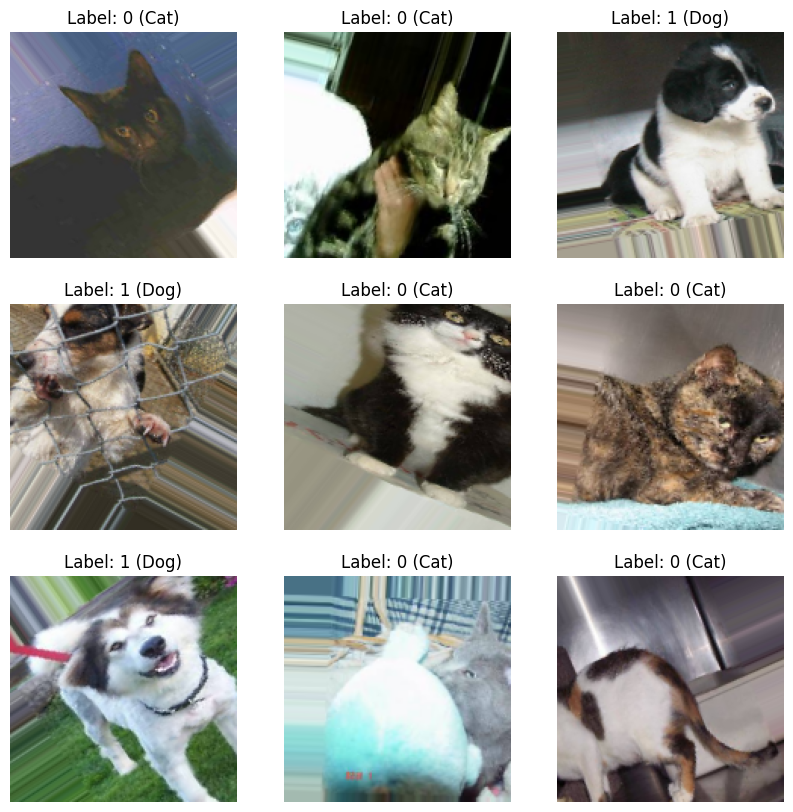

In [38]:
# ジェネレーターから生成されるデータの確認
# 最初のバッチを取得
images, labels = next(train_generator)

print(f"\n最初のバッチの画像形状: {images.shape}") # (batch_size, IMG_HEIGHT, IMG_WIDTH, 3)
print(f"最初のバッチのラベル形状: {labels.shape}") # (batch_size,)
print(f"最初のバッチのラベル (0: 猫, 1: 犬): {labels}")

# データ拡張された画像の一部を表示
plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(f"Label: {int(labels[i])} ({'Dog' if labels[i] == 1 else 'Cat'})")
    plt.axis("off")
plt.show()

モデルの構築（コーディング）

In [39]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16 # VGG16モデルをインポート

# --- データ準備フェーズで定義した変数 ---
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

# 1. VGG系モデルのロード
# VGG16モデルを、ImageNetで事前学習された重みでロードする
# include_top=False: モデルの最上位（分類器）の全結合層を含めないようにする
#                    これにより、VGG16は特徴抽出器としてのみ機能する
# input_shape: モデルへの入力画像の形状を指定(高さ, 幅, チャンネル数)
base_model = VGG16(weights='imagenet',
                   include_top=False,
                   input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

base_model.summary() # ベースモデルの構造を確認

# 2. 転移学習の適用: ベースモデルの層をフリーズし、新しい分類層を追加
# ベースモデルの全ての層をフリーズする
# これにより、事前学習済みの重みが訓練中に更新されなくする
# VGG16が学習した強力な特徴抽出能力をそのまま利用する
base_model.trainable = False

# 新しい分類器（ヘッド）を構築
model = models.Sequential([
    base_model, # VGG16ベースモデルを組み込む
    layers.Flatten(), # 特徴マップを1次元に変換
    layers.Dense(256, activation='relu'), # 全結合層 (256ユニット)
    layers.Dropout(0.5), # 過学習を防ぐためのドロップアウト層 (50%のニューロンを無効化)
    layers.Dense(1, activation='sigmoid') # 出力層: 二値分類のため1ユニット、sigmoid活性化関数
])


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:

model.summary() # 構築したモデル全体の構造を確認

# 3. モデルのコンパイル
# オプティマイザ、損失関数、評価指標を設定してモデルをコンパイルします。
# optimizer: Adam (一般的な最適化アルゴリズム)
# loss: BinaryCrossentropy (二値分類のための損失関数)
# metrics: accuracy (評価指標として精度を使用)
model.compile(optimizer=optimizers.Adam(learning_rate=0.0001), # 少し小さめの学習率を設定
              loss=losses.BinaryCrossentropy(),
              metrics=['accuracy'])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

学習と評価１: モデルの学習 (初期訓練)

In [41]:
# --- モデルの学習 (初期訓練) ---
print("---モデルの初期訓練開始---")

# モデルの訓練
# steps_per_epoch: 1エポックあたりのステップ数。訓練データの総数をバッチサイズで割った値。
# validation_steps: 1エポックあたりの検証ステップ数。検証データの総数をバッチサイズで割った値。
# epochs: 全ての訓練データを何回繰り返して学習させるか。
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=10, # まずは少なめのエポック数で様子をみる
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("---モデルの初期訓練完了---")

---モデルの初期訓練開始---
Epoch 1/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 838s 3s/step - accuracy: 0.7640 - loss: 0.4755 - val_accuracy: 0.8769 - val_loss: 0.2762
Epoch 2/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 304s 1s/step - accuracy: 0.7812 - loss: 0.4861 - val_accuracy: 0.8777 - val_loss: 0.2758
Epoch 3/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 835s 3s/step - accuracy: 0.8289 - loss: 0.3745 - val_accuracy: 0.9024 - val_loss: 0.2416
Epoch 4/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 297s 1s/step - accuracy: 0.8125 - loss: 0.3353 - val_accuracy: 0.9003 - val_loss: 0.2445
Epoch 5/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 825s 3s/step - accuracy: 0.8383 - loss: 0.3535 - val_accuracy: 0.9056 - val_loss: 0.2234
Epoch 6/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.8438 - loss: 0.3109 - val_accuracy: 0.9071 - val_loss: 0.2211
Epoch 7/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 826s 3s/step - accuracy: 0.8486 - loss: 0.3393 - val_accuracy: 0.9003 - val_loss: 0.2385
Epoch 8/10
249/249 ━━━━━━━━━━━━━━━━━━━━ 294s 1s/step - accuracy: 0.9062 - loss: 

学習と評価２: 学習曲線のプロット (初期訓練後)


---初期訓練の学習曲線をプロット---


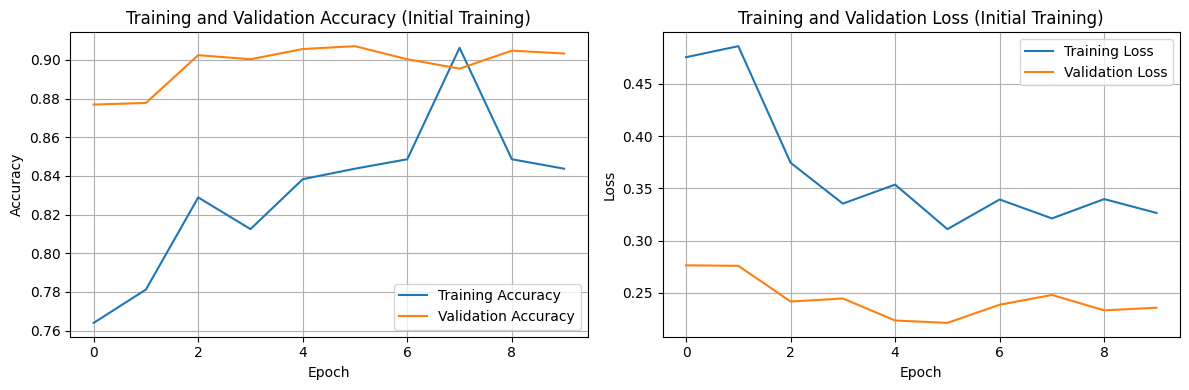

In [42]:
# --- 学習曲線のプロット (初期訓練後) ---
print("\n---初期訓練の学習曲線をプロット---")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc)) # エポック数の範囲

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Initial Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Initial Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

学習と評価３: ファインチューニング

In [27]:
# --- ファインチューニング ---
print("\n---ファインチューニング開始---")

# VGG16ベースモデルのフリーズを解除（一部または全体）
# 一般的に、より深い層（最後の畳み込みブロックなど）をアンフリーズする
# VGG16の層構造を確認し、どの層から訓練可能にするか決める
# base_model.summary() を実行して層の名前を確認するとよい

# ここでは、VGG16の最後の畳み込みブロック（block5_conv1以降）を訓練可能にする
# VGG16の層は全部で19層あり、block5_conv1は15番目の層
# VGG16の層を後ろから数えて、特定の層以降を trainable=True に設定
# 例: 最後の数層だけを訓練可能にする
fine_tune_at = 100 # VGG16の層のインデックス。このインデックス以降の層を訓練可能にする

# VGG16の層をループし、指定した層以降を訓練可能に設定
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization): # BatchNormalization層は常に訓練可能にするのが一般的
        layer.trainable = True
    elif layer.name.startswith('block5_'): # block5_conv1, block5_conv2, block5_conv3
        layer.trainable = True
    else:
        layer.trainable = False

# または、よりシンプルに特定の層数以降を訓練可能にする
# for layer in base_model.layers[fine_tune_at:]:
#     layer.trainable = True

# for layer in base_model.layers[:fine_tune_at]:
#     layer.trainable = False

# モデル全体の trainable 設定を更新
base_model.trainable = True # VGG16全体を訓練可能に設定し、その後個別にフリーズ/アンフリーズを設定

# モデルを再コンパイル
# ファインチューニングでは、非常に低い学習率を使用することが重要
model.compile(optimizer=optimizers.Adam(learning_rate=0.00001), # 非常に低い学習率
              loss=losses.BinaryCrossentropy(),
              metrics=['accuracy'])

print("\nファインチューニングのためのモデル再コンパイル完了")
model.summary() # ファインチューニング後のモデル全体の構造を確認 (Trainable paramsが増えているはず)

# ファインチューニングの訓練
# 初期訓練からの続きとしてエポック数を調整する
# 例えば、初期訓練で10エポック、ファインチューニングでさらに10エポック行う場合、
# initial_epochs = 10
# fine_tune_epochs = 10
# total_epochs = initial_epochs + fine_tune_epochs
# history_fine = model.fit(...) の epochs を fine_tune_epochs に設定し、initial_epoch=initial_epochs を追加
# ここではシンプルに、追加で10エポック訓練する
fine_tune_epochs = 10
total_epochs = len(history.epoch) + fine_tune_epochs # 初期訓練のエポック数にファインチューニングのエポック数を加える

history_fine = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1], # 初期訓練の最終エポックから開始
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE
)

print("---ファインチューニング完了---")


---ファインチューニング開始---

ファインチューニングのためのモデル再コンパイル完了


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 10/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2762s 11s/step - accuracy: 0.9092 - loss: 0.2172 - val_accuracy: 0.9628 - val_loss: 0.0946
Epoch 11/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 204s 817ms/step - accuracy: 0.9375 - loss: 0.1590 - val_accuracy: 0.9635 - val_loss: 0.0923
Epoch 12/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2415s 10s/step - accuracy: 0.9357 - loss: 0.1458 - val_accuracy: 0.9625 - val_loss: 0.1075
Epoch 13/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 191s 761ms/step - accuracy: 0.9062 - loss: 0.1118 - val_accuracy: 0.9573 - val_loss: 0.1229
Epoch 14/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2413s 10s/step - accuracy: 0.9509 - loss: 0.1254 - val_accuracy: 0.9597 - val_loss: 0.1005
Epoch 15/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 226s 887ms/step - accuracy: 1.0000 - loss: 0.0294 - val_accuracy: 0.9556 - val_loss: 0.1106
Epoch 16/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 2400s 10s/step - accuracy: 0.9619 - loss: 0.0976 - val_accuracy: 0.9778 - val_loss: 0.0593
Epoch 17/20
240/240 ━━━━━━━━━━━━━━━━━━━━ 192s 763ms/step - accuracy: 0.93

学習と評価４: 学習曲線のプロット (ファインチューニング後)


---ファインチューニングを含む学習曲線をプロット---


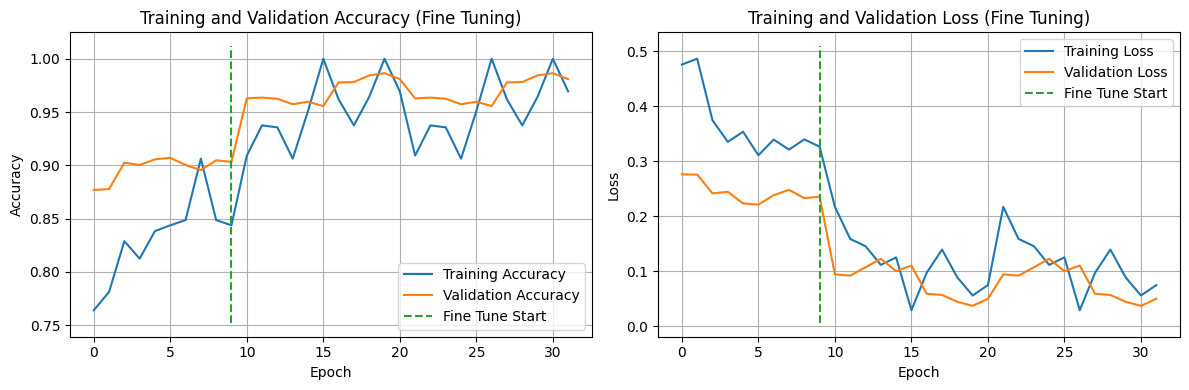

In [44]:
# --- 学習曲線のプロット (ファインチューニング後) ---
print("\n---ファインチューニングを含む学習曲線をプロット---")

# 初期訓練とファインチューニングの履歴を結合
# ここで `history.history` と `history_fine.history` の長さが異なる可能性を考慮
# 結合する前に、それぞれのリストの長さを確認するのが安全です。

# まず、初期訓練の履歴をコピー
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# ファインチューニングの履歴を結合
# history_fine.history['accuracy'] が存在し、かつ中身があることを確認
if 'accuracy' in history_fine.history and len(history_fine.history['accuracy']) > 0:
    acc.extend(history_fine.history['accuracy'])
    val_acc.extend(history_fine.history['val_accuracy'])
    loss.extend(history_fine.history['loss'])
    val_loss.extend(history_fine.history['val_loss'])
else:
    print("ファインチューニングの履歴が不完全または存在しないため、初期訓練の履歴のみでプロット")

# 実際に訓練された総エポック数に合わせて epochs_range を設定
epochs_range = range(len(acc)) # acc の実際の長さに合わせる

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
# ファインチューニング開始点も、history.epochの実際の長さに合わせる
plt.plot([len(history.epoch)-1, len(history.epoch)-1], plt.ylim(), label='Fine Tune Start', linestyle='--')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy (Fine Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
# ファインチューニング開始点も、history.epochの実際の長さに合わせる
plt.plot([len(history.epoch)-1, len(history.epoch)-1], plt.ylim(), label='Fine Tune Start', linestyle='--')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss (Fine Tuning)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

学習と評価５: モデルの評価 (テストデータ)


--- テストデータでモデルを評価します ---
62/62 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8876 - loss: 0.2657

テストデータでの損失: 0.2657
テストデータでの精度: 0.8876

--- 詳細な評価レポート ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step
Classification Report:
              precision    recall  f1-score   support

        cats       0.93      0.84      0.88      1000
        dogs       0.85      0.94      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000


Confusion Matrix:
[[840 160]
 [ 64 936]]


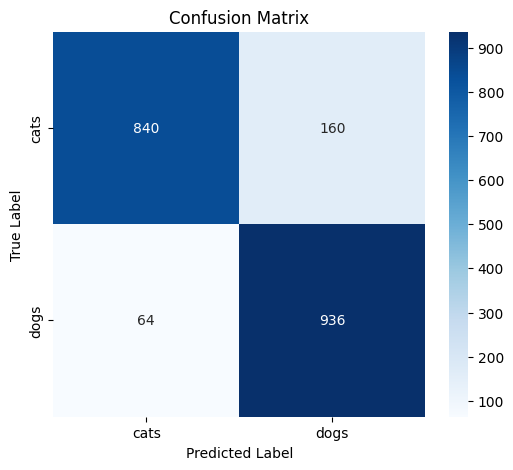

In [45]:
# --- モデルの評価 (テストデータ) ---
print("\n--- テストデータでモデルを評価します ---")

test_loss, test_accuracy = model.evaluate(test_generator,
                                          steps=test_generator.samples // BATCH_SIZE)

print(f"\nテストデータでの損失: {test_loss:.4f}")
print(f"テストデータでの精度: {test_accuracy:.4f}")

# オプション: より詳細な評価レポート
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- 詳細な評価レポート ---")

# テストデータの予測
# shuffle=False でジェネレーターを作成しているので、predict_generatorの出力順は test_generator.filenames の順序と一致する
test_generator.reset() # ジェネレーターをリセットして最初から読み込む
predictions = model.predict(test_generator, steps=test_generator.samples // BATCH_SIZE + 1)
predicted_classes = (predictions > 0.5).astype(int).flatten() # 0.5を閾値としてクラスを決定

# 真のラベルを取得
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys()) # クラス名 (例: ['cats', 'dogs'])

# classification_report
print("Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# confusion_matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

# 混同行列の可視化 (オプション)
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

学習と評価６: 新しい画像での推論 (AIの動作確認)


---新しい画像でモデルの予測を試す---
選択された画像: cats_and_dogs_small\test\dogs\dog.4106.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
予測: Dog (信頼度: 89.26%)
正解: Dog


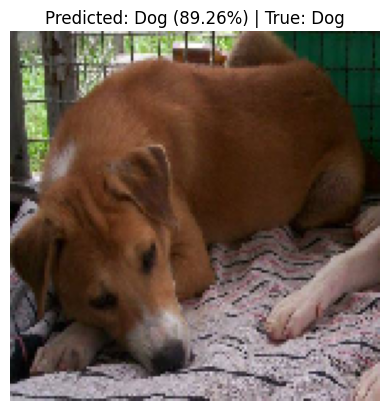

In [46]:
# --- 新しい画像での推論 ---
print("\n---新しい画像でモデルの予測を試す---")

# 推論したい画像ファイルのパスを指定
# 例: テストデータセットからランダムに1枚選ぶ、または手動で用意した画像を使う
# ここではテストデータセットからランダムに1枚選ぶ
import random

# テストデータセットのファイルパスリストを取得
test_image_paths = []
for root, _, files in os.walk(test_dir):
    for file in files:
        if file.endswith('.jpg'):
            test_image_paths.append(os.path.join(root, file))

if not test_image_paths:
    print("テストデータセットに画像が見つかりません。")
else:
    random_image_path = random.choice(test_image_paths)
    print(f"選択された画像: {random_image_path}")

    # 画像の読み込みと前処理
    img = keras.preprocessing.image.load_img(
        random_image_path, target_size=(IMG_HEIGHT, IMG_WIDTH)
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # バッチ次元を追加 (1, height, width, channels)
    img_array = img_array / 255.0 # 0-1に正規化 (訓練時と同じ前処理)

    # モデルによる予測
    prediction = model.predict(img_array)[0][0] # 予測結果は確率値 (0-1)

    # 予測結果の解釈
    if prediction > 0.5:
        predicted_label = "Dog"
        confidence = prediction * 100
    else:
        predicted_label = "Cat"
        confidence = (1 - prediction) * 100

    true_label = "Dog" if "dogs" in random_image_path else "Cat"

    print(f"予測: {predicted_label} (信頼度: {confidence:.2f}%)")
    print(f"正解: {true_label}")

    # 画像の表示
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_label} ({confidence:.2f}%) | True: {true_label}")
    plt.axis('off')
    plt.show()